In [ ]:
# Step 1: Upload your dataset
from google.colab import files
uploaded = files.upload()

Saving household_energy_consumption.csv to household_energy_consumption.csv


In [ ]:
# Step 2: Load dataset using pandas
import pandas as pd

df = pd.read_csv("household_energy_consumption.csv")
print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


In [ ]:
# Step 3: Preview the first few rows of the dataset
df.head()


,Household_ID,Date,Energy_Consumption_kWh,Household_Size,Avg_Temperature_C,Has_AC,Peak_Hours_Usage_kWh
0,H00001,2025-04-01,8.4,4,17.8,No,3.2
1,H00001,2025-04-02,7.9,4,17.3,No,2.8
2,H00001,2025-04-03,9.2,4,18.6,No,3.0
3,H00001,2025-04-04,7.9,4,18.2,No,2.7
4,H00001,2025-04-05,9.6,4,11.9,No,3.2


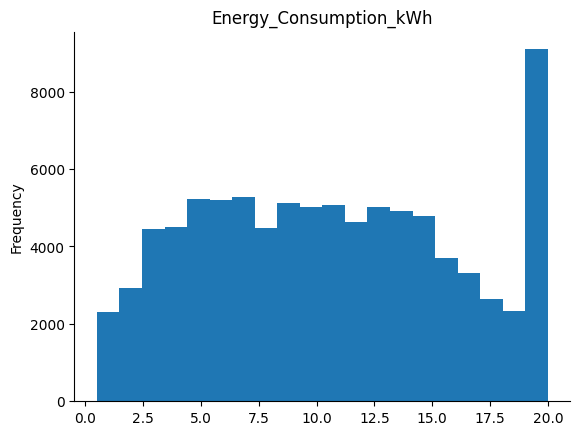

In [ ]:
# @title Energy_Consumption_kWh

from matplotlib import pyplot as plt
df['Energy_Consumption_kWh'].plot(kind='hist', bins=20, title='Energy_Consumption_kWh')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
# Step 4: Check data types and column info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Household_ID            90000 non-null  object 
 1   Date                    90000 non-null  object 
 2   Energy_Consumption_kWh  90000 non-null  float64
 3   Household_Size          90000 non-null  int64  
 4   Avg_Temperature_C       90000 non-null  float64
 5   Has_AC                  90000 non-null  object 
 6   Peak_Hours_Usage_kWh    90000 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 4.8+ MB


In [ ]:
# Step 5: Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df['Date'].head()


,Date
0,2025-04-01
1,2025-04-02
2,2025-04-03
3,2025-04-04
4,2025-04-05


In [ ]:
# Step 6: Convert categorical columns
df['Has_AC'] = df['Has_AC'].astype('category')
df['Household_ID'] = df['Household_ID'].astype('category')
df.dtypes


,0
Household_ID,category
Date,datetime64[ns]
Energy_Consumption_kWh,float64
Household_Size,int64
Avg_Temperature_C,float64
Has_AC,category
Peak_Hours_Usage_kWh,float64


In [ ]:
# Step 7: Check for missing values
df.isnull().sum()


,0
Household_ID,0
Date,0
Energy_Consumption_kWh,0
Household_Size,0
Avg_Temperature_C,0
Has_AC,0
Peak_Hours_Usage_kWh,0


In [ ]:
# Impute missing values using median for numerical columns
df['Energy_Consumption_kWh'].fillna(df['Energy_Consumption_kWh'].median(), inplace=True)
df['Avg_Temperature_C'].fillna(df['Avg_Temperature_C'].median(), inplace=True)
df['Peak_Hours_Usage_kWh'].fillna(df['Peak_Hours_Usage_kWh'].median(), inplace=True)


<ipython-input-10-bfd968e7625d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Energy_Consumption_kWh'].fillna(df['Energy_Consumption_kWh'].median(), inplace=True)
<ipython-input-10-bfd968e7625d>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

In [ ]:
# Fill missing AC values with the most common (mode)
df['Has_AC'].fillna(df['Has_AC'].mode()[0], inplace=True)


<ipython-input-11-74dafd6c4085>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Has_AC'].fillna(df['Has_AC'].mode()[0], inplace=True)


In [ ]:
# Step 10: Add new feature columns
df['DayOfWeek'] = df['Date'].dt.day_name()
df['IsWeekend'] = df['DayOfWeek'].isin(['Saturday', 'Sunday']).map({True: 'Yes', False: 'No'})
df[['Date', 'DayOfWeek', 'IsWeekend']].head()


,Date,DayOfWeek,IsWeekend
0,2025-04-01,Tuesday,No
1,2025-04-02,Wednesday,No
2,2025-04-03,Thursday,No
3,2025-04-04,Friday,No
4,2025-04-05,Saturday,Yes


In [ ]:
# Step 11: Save cleaned data to new CSV
df.to_csv("cleaned_energy_data.csv", index=False)
print("✅ Cleaned data saved!")


✅ Cleaned data saved!


In [ ]:
# Step 12: Download the cleaned CSV file
from google.colab import files
files.download("cleaned_energy_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>